# 🔮 Hotel Revenue Forecasting — 2026 Prediction
### Capstone Project | Pratik Chorghe | Data Analyst
**Model:** Facebook Prophet + Linear Regression  
**Goal:** Predict 2026 quarterly revenue by Chain and Country  
**Output:** `hotel_forecast_2026.csv` → import into Power BI

---
> **Why forecasting?**  
> Most analysts only show historical data. Adding a 2026 forecast shows  
> you can support **future business decisions** — a senior analyst skill.


## 📦 Section 1 — Import Libraries

In [2]:
# Install required libraries
import sys
!{sys.executable} -m pip install prophet scikit-learn --quiet
print("✅ Installation complete — now run the next cells")

✅ Installation complete — now run the next cells


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from prophet import Prophet
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder

plt.rcParams['figure.figsize'] = (13, 5)
plt.rcParams['font.family']    = 'sans-serif'
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False

print("✅ All libraries imported")
print(f"   Prophet   : OK")
print(f"   Sklearn   : OK")
print(f"   Pandas    : {pd.__version__}")


✅ All libraries imported
   Prophet   : OK
   Sklearn   : OK
   Pandas    : 2.3.3


## 📂 Section 2 — Load Cleaned Data

In [5]:
# Load the cleaned fact table (output from Notebook 1)
# If you don't have the CSV yet, load directly from Excel
try:
    df = pd.read_csv('hotel_fact_cleaned.csv')
    print(f"✅ Loaded from CSV: {df.shape[0]:,} rows")
except FileNotFoundError:
    df = pd.read_excel('hotel_star_schema_5500rows.xlsx', sheet_name='Fact_Revenue')
    print(f"✅ Loaded from Excel: {df.shape[0]:,} rows")

# Rename occupancy column if needed
df.rename(columns={'Occupancy_%': 'Occupancy_Pct', 'GOP_%': 'GOP_Pct'}, inplace=True)

# Use only Reported data for forecasting (exclude Estimated 2025)
df_reported = df[df['Revenue_Type'] == 'Reported'].copy()
print(f"   Reported rows (2019-2024): {df_reported.shape[0]:,}")
print(f"   Years available: {sorted(df_reported['Year'].unique())}")
print(f"   Chains: {df_reported['Chain_ID'].nunique()}")
print(f"   Countries: {df_reported['Country'].nunique()}")


✅ Loaded from CSV: 5,500 rows
   Reported rows (2019-2024): 4,712
   Years available: [np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]
   Chains: 12
   Countries: 25


In [6]:
# Create a quarter-to-month mapping for Prophet (needs datetime)
quarter_month = {'Q1': '01', 'Q2': '04', 'Q3': '07', 'Q4': '10'}

df_reported['ds'] = pd.to_datetime(
    df_reported['Year'].astype(str) + '-' +
    df_reported['Quarter'].map(quarter_month) + '-01'
)

print("✅ Date column created")
df_reported[['Year','Quarter','ds','Revenue_USD']].head(5)


✅ Date column created


,Year,Quarter,ds,Revenue_USD
0,2020,Q2,2020-04-01,496896
1,2022,Q2,2022-04-01,993720
2,2020,Q3,2020-07-01,7142990
3,2023,Q2,2023-04-01,614250
4,2019,Q4,2019-10-01,1622549


## 📈 Section 3 — Global Revenue Trend (Prophet Model)
> **What is Prophet?**  
> Facebook's open-source forecasting tool. It handles seasonality,  
> holidays, and trend changes automatically. Perfect for quarterly data.


In [7]:
# ── 3.1  Aggregate global quarterly revenue ──
global_quarterly = df_reported.groupby('ds')['Revenue_USD'].sum().reset_index()
global_quarterly.columns = ['ds', 'y']
global_quarterly = global_quarterly.sort_values('ds').reset_index(drop=True)
global_quarterly['y_M'] = global_quarterly['y'] / 1e6

print("Global quarterly revenue shape:", global_quarterly.shape)
global_quarterly[['ds','y_M']].tail(8)


Global quarterly revenue shape: (24, 3)


,ds,y_M
16,2023-01-01,751.039319
17,2023-04-01,859.988222
18,2023-07-01,801.432785
19,2023-10-01,690.043701
20,2024-01-01,907.910156
21,2024-04-01,856.785911
22,2024-07-01,968.866931
23,2024-10-01,959.271584


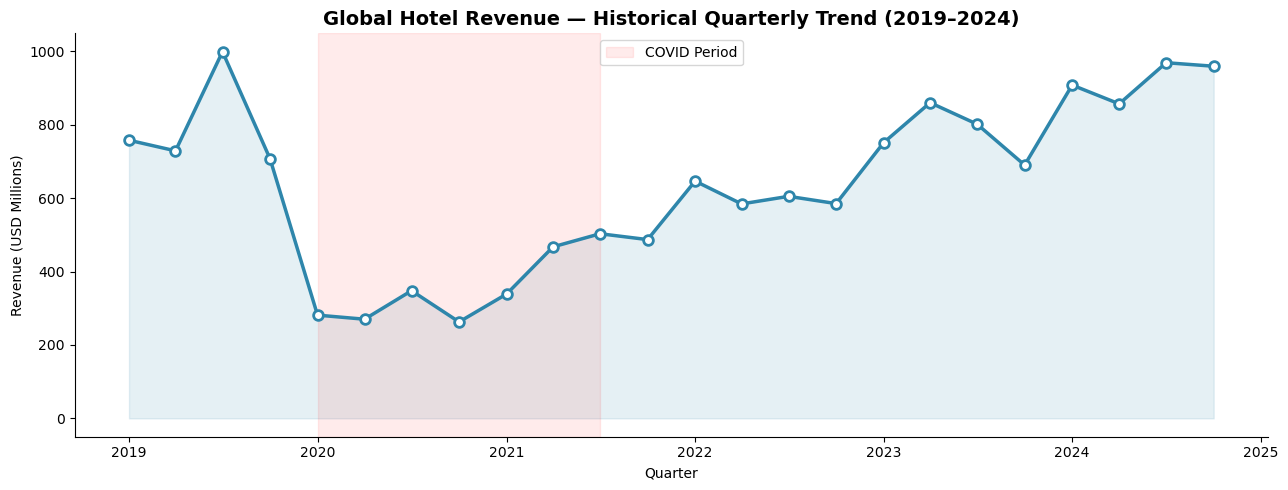

✅ Saved: historical_trend.png


In [8]:
# ── 3.2  Plot historical trend ──
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(global_quarterly['ds'], global_quarterly['y_M'],
        marker='o', linewidth=2.5, color='#2E86AB',
        markersize=7, markerfacecolor='white', markeredgewidth=2)
ax.fill_between(global_quarterly['ds'], global_quarterly['y_M'], alpha=0.12, color='#2E86AB')
ax.set_title('Global Hotel Revenue — Historical Quarterly Trend (2019–2024)',
             fontsize=14, fontweight='bold')
ax.set_ylabel('Revenue (USD Millions)')
ax.set_xlabel('Quarter')
ax.axvspan(pd.Timestamp('2020-01-01'), pd.Timestamp('2021-07-01'),
           alpha=0.08, color='red', label='COVID Period')
ax.legend()
plt.tight_layout()
plt.savefig('historical_trend.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: historical_trend.png")


In [9]:
# ── 3.3  Train Prophet model ──
model_global = Prophet(
    seasonality_mode='multiplicative',   # revenue scales with trend
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    changepoint_prior_scale=0.15,        # flexibility for COVID dip
    interval_width=0.90                  # 90% confidence interval
)

# Add COVID as a special event (major dip)
covid_lockdowns = pd.DataFrame({
    'holiday': 'COVID Lockdown',
    'ds': pd.to_datetime(['2020-01-01','2020-04-01','2020-07-01','2020-10-01',
                          '2021-01-01','2021-04-01']),
    'lower_window': 0,
    'upper_window': 1,
})
model_global.add_country_holidays(country_name='US')

model_global.fit(global_quarterly[['ds','y']])
print("✅ Prophet model trained on global quarterly data")


23:35:12 - cmdstanpy - INFO - Chain [1] start processing
23:35:14 - cmdstanpy - INFO - Chain [1] done processing


✅ Prophet model trained on global quarterly data


In [10]:
# ── 3.4  Forecast 2025 + 2026 (8 future quarters) ──
future = model_global.make_future_dataframe(periods=8, freq='QS')
forecast_global = model_global.predict(future)

# Extract forecast values
forecast_future = forecast_global[forecast_global['ds'] > global_quarterly['ds'].max()].copy()
forecast_future['yhat_M']       = (forecast_future['yhat'] / 1e6).round(2)
forecast_future['yhat_lower_M'] = (forecast_future['yhat_lower'] / 1e6).round(2)
forecast_future['yhat_upper_M'] = (forecast_future['yhat_upper'] / 1e6).round(2)
forecast_future['Year']         = forecast_future['ds'].dt.year
forecast_future['Quarter']      = forecast_future['ds'].dt.month.map(
    {1:'Q1', 4:'Q2', 7:'Q3', 10:'Q4'}
)

print("=== GLOBAL FORECAST 2025–2026 ===")
print(forecast_future[['ds','Year','Quarter','yhat_M','yhat_lower_M','yhat_upper_M']].to_string(index=False))


=== GLOBAL FORECAST 2025–2026 ===
        ds  Year Quarter  yhat_M  yhat_lower_M  yhat_upper_M
2025-01-01  2025      Q1  550.13        266.50        810.86
2025-04-01  2025      Q2  715.67        455.29        978.45
2025-07-01  2025      Q3  812.09        545.41       1105.66
2025-10-01  2025      Q4  732.38        475.16       1007.67
2026-01-01  2026      Q1  851.57        572.53       1132.74
2026-04-01  2026      Q2  874.80        580.08       1126.92
2026-07-01  2026      Q3  965.60        703.31       1231.75
2026-10-01  2026      Q4  816.90        537.73       1083.14


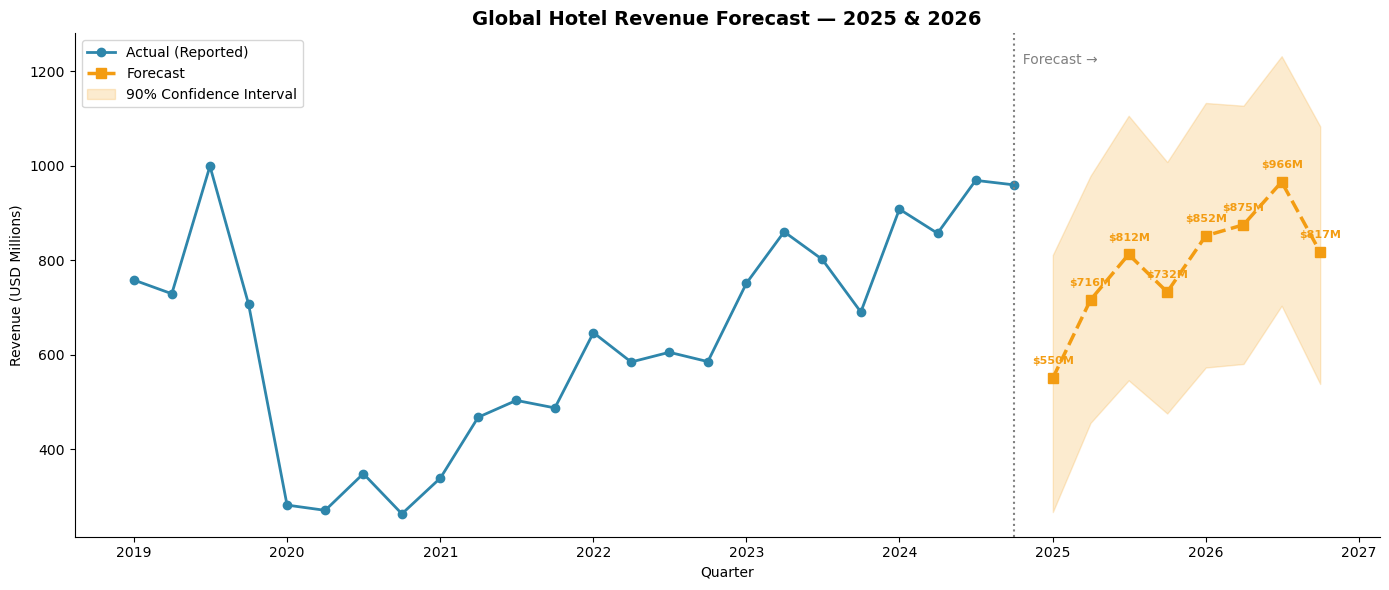

✅ Saved: forecast_global.png


In [11]:
# ── 3.5  Plot forecast ──
fig, ax = plt.subplots(figsize=(14, 6))

# Historical
ax.plot(global_quarterly['ds'], global_quarterly['y_M'],
        marker='o', linewidth=2, color='#2E86AB', label='Actual (Reported)', markersize=6)

# Forecast
ax.plot(forecast_future['ds'], forecast_future['yhat_M'],
        marker='s', linewidth=2.5, color='#F39C12', linestyle='--',
        label='Forecast', markersize=7)

# Confidence interval
ax.fill_between(forecast_future['ds'],
                forecast_future['yhat_lower_M'],
                forecast_future['yhat_upper_M'],
                alpha=0.2, color='#F39C12', label='90% Confidence Interval')

# Divider line
ax.axvline(x=global_quarterly['ds'].max(), color='gray', linestyle=':', linewidth=1.5)
ax.text(global_quarterly['ds'].max(), ax.get_ylim()[1]*0.95,
        '  Forecast →', color='gray', fontsize=10)

# Annotate forecast values
for _, row in forecast_future.iterrows():
    ax.annotate(f"${row['yhat_M']:.0f}M",
                (row['ds'], row['yhat_M']),
                textcoords='offset points', xytext=(0, 10),
                ha='center', fontsize=8, color='#F39C12', fontweight='bold')

ax.set_title('Global Hotel Revenue Forecast — 2025 & 2026',
             fontsize=14, fontweight='bold')
ax.set_ylabel('Revenue (USD Millions)')
ax.set_xlabel('Quarter')
ax.legend()
plt.tight_layout()
plt.savefig('forecast_global.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: forecast_global.png")


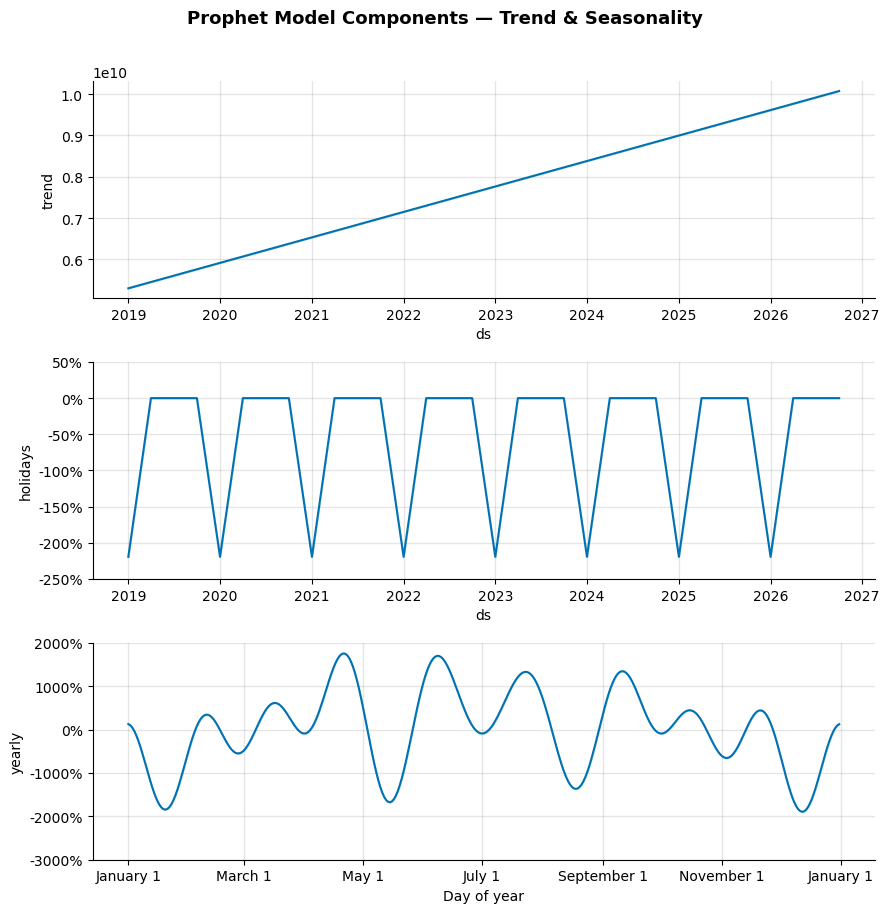

✅ Saved: prophet_components.png


In [12]:
# ── 3.6  Prophet components plot (trend + seasonality) ──
fig2 = model_global.plot_components(forecast_global)
plt.suptitle('Prophet Model Components — Trend & Seasonality', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('prophet_components.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: prophet_components.png")


## 🏨 Section 4 — Chain-Level Forecast (Linear Regression)
> Prophet works best with longer time series.  
> For individual chains (fewer data points), we use  
> **Linear Regression** — simpler but very explainable in interviews.


In [13]:
# ── 4.1  Prepare chain-level yearly data ──
chain_yearly = df_reported.groupby(['Chain_ID','Year'])['Revenue_USD'].sum().reset_index()
chain_yearly['Revenue_M'] = chain_yearly['Revenue_USD'] / 1e6

# Show summary
pivot = chain_yearly.pivot(index='Chain_ID', columns='Year', values='Revenue_M').round(2)
print("=== Chain Revenue by Year (USD Millions) ===")
print(pivot.to_string())


=== Chain Revenue by Year (USD Millions) ===
Year        2019    2020    2021    2022    2023    2024
Chain_ID                                                
CHN01     312.85  133.85  190.26  349.16  324.44  400.78
CHN02     354.85  112.28  168.63  247.07  308.27  373.36
CHN03     245.75  125.11  260.84  285.51  263.03  395.43
CHN04     319.87  122.77  158.13  241.16  299.28  374.68
CHN05     398.49  108.87  227.49  277.35  476.46  454.41
CHN06      82.34   31.39   55.89   81.14   70.79   92.64
CHN07     106.88   39.45   65.67   68.80   95.86  133.37
CHN08     296.38  118.62  176.73  206.74  292.65  341.40
CHN09     154.58   77.64  110.69  136.30  166.03  227.13
CHN10     418.09  137.69  151.07  252.16  352.89  414.30
CHN11     122.96   61.35   69.63   96.67  123.19  197.67
CHN12     379.73   92.98  160.98  178.48  329.62  287.67


In [14]:
# ── 4.2  Train Linear Regression per chain → predict 2026 ──
from sklearn.linear_model import LinearRegression
import numpy as np

forecast_chain_rows = []
years_train = [2019, 2020, 2021, 2022, 2023, 2024]

for chain_id in chain_yearly['Chain_ID'].unique():
    chain_data = chain_yearly[chain_yearly['Chain_ID'] == chain_id].sort_values('Year')

    if len(chain_data) < 4:
        continue

    X = chain_data['Year'].values.reshape(-1, 1)
    y = chain_data['Revenue_M'].values

    model = LinearRegression()
    model.fit(X, y)

    # Predict 2025 + 2026
    for yr in [2025, 2026]:
        pred = model.predict([[yr]])[0]
        # Apply realistic cap — no chain should grow >25% over 2024
        base_2024 = chain_data[chain_data['Year']==2024]['Revenue_M'].values
        if len(base_2024) > 0:
            pred = min(pred, base_2024[0] * 1.25)
            pred = max(pred, base_2024[0] * 0.70)  # floor at -30%

        # Split into quarters using historical Q weights
        chain_q = df_reported[df_reported['Chain_ID'] == chain_id].groupby('Quarter')['Revenue_USD'].mean()
        q_total = chain_q.sum()
        q_weights = (chain_q / q_total).to_dict() if q_total > 0 else {'Q1':0.25,'Q2':0.25,'Q3':0.25,'Q4':0.25}

        for q, w in q_weights.items():
            forecast_chain_rows.append({
                'Chain_ID':      chain_id,
                'Year':          yr,
                'Quarter':       q,
                'Forecast_Revenue_M': round(pred * w, 3),
                'Model':         'Linear Regression',
                'Data_Type':     'Forecast'
            })

df_forecast_chain = pd.DataFrame(forecast_chain_rows)
print(f"✅ Chain forecasts generated: {len(df_forecast_chain)} rows")
print(f"   Chains forecasted: {df_forecast_chain['Chain_ID'].nunique()}")


✅ Chain forecasts generated: 96 rows
   Chains forecasted: 12


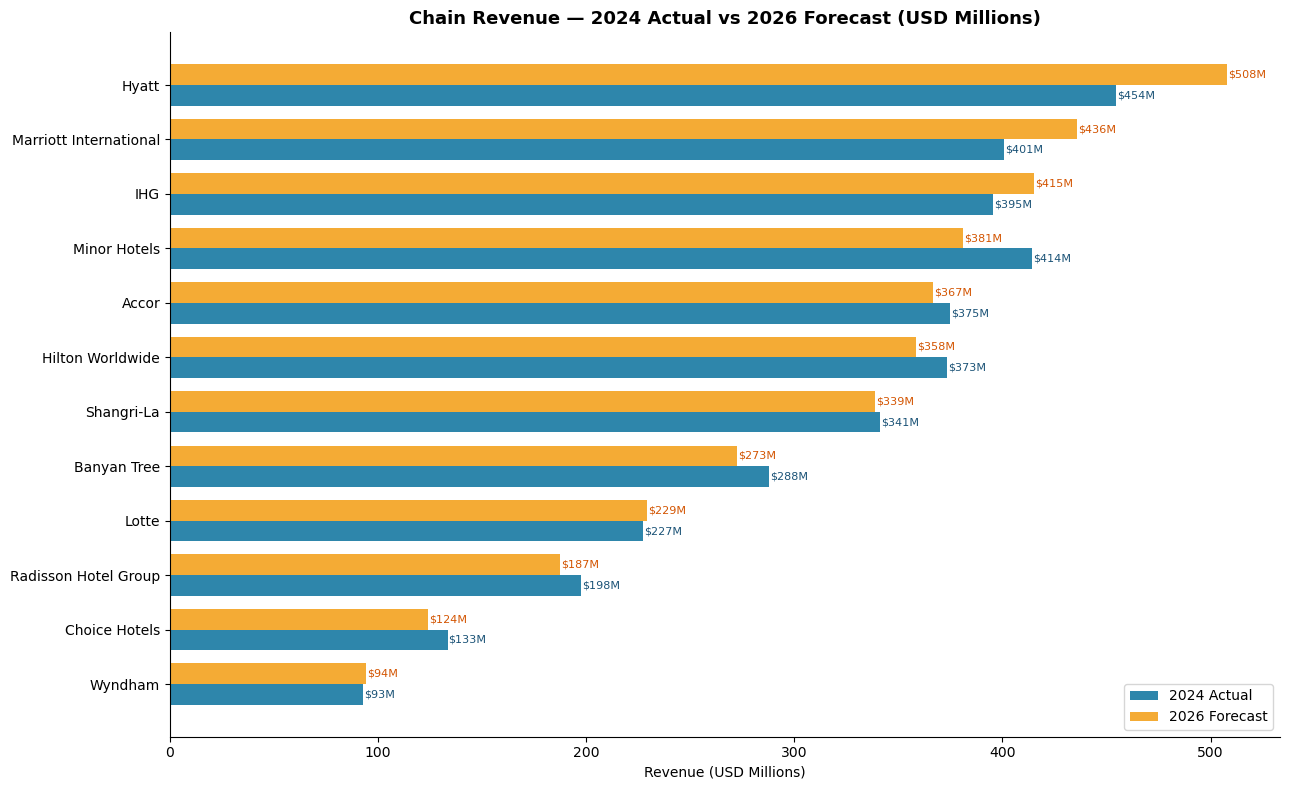

✅ Saved: forecast_by_chain.png


In [21]:
# ── 4.3  Visualise chain forecasts ──

# Chain ID to Name mapping — no file needed
chain_id_to_name = {
    'CHN01': 'Marriott International',
    'CHN02': 'Hilton Worldwide',
    'CHN03': 'IHG',
    'CHN04': 'Accor',
    'CHN05': 'Hyatt',
    'CHN06': 'Wyndham',
    'CHN07': 'Choice Hotels',
    'CHN08': 'Shangri-La',
    'CHN09': 'Lotte',
    'CHN10': 'Minor Hotels',
    'CHN11': 'Radisson Hotel Group',
    'CHN12': 'Banyan Tree',
}

# Map Chain_ID → Chain_Name
df_forecast_chain['Chain_Name'] = df_forecast_chain['Chain_ID'].map(chain_id_to_name)
chain_yearly['Chain_Name']      = chain_yearly['Chain_ID'].map(chain_id_to_name)

# Aggregate by Chain_Name
chain_2026 = (df_forecast_chain[df_forecast_chain['Year'] == 2026]
              .groupby('Chain_Name')['Forecast_Revenue_M']
              .sum()
              .sort_values(ascending=True))

chain_2024_act = (chain_yearly[chain_yearly['Year'] == 2024]
                  .groupby('Chain_Name')['Revenue_M']
                  .sum())

# Plot
fig, ax = plt.subplots(figsize=(13, 8))
x     = np.arange(len(chain_2026))
width = 0.38

ax.barh(x - width/2,
        [chain_2024_act.get(c, 0) for c in chain_2026.index],
        width, label='2024 Actual', color='#2E86AB')

ax.barh(x + width/2,
        chain_2026.values,
        width, label='2026 Forecast', color='#F39C12', alpha=0.85)

ax.set_yticks(x)
ax.set_yticklabels(chain_2026.index, fontsize=10)
ax.set_title('Chain Revenue — 2024 Actual vs 2026 Forecast (USD Millions)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Revenue (USD Millions)')
ax.legend()

# Value labels on bars
for i, (act_val, fc_val) in enumerate(zip(
    [chain_2024_act.get(c, 0) for c in chain_2026.index],
    chain_2026.values
)):
    ax.text(act_val + 0.5, i - width/2, f'${act_val:.0f}M', va='center', fontsize=8, color='#1a5276')
    ax.text(fc_val  + 0.5, i + width/2, f'${fc_val:.0f}M',  va='center', fontsize=8, color='#d35400')

plt.tight_layout()
plt.savefig('forecast_by_chain.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: forecast_by_chain.png")

## 🌍 Section 5 — Country-Level Forecast

In [16]:
# ── 5.1  Country yearly revenue ──
country_yearly = df_reported.groupby(['Country','Year'])['Revenue_USD'].sum().reset_index()
country_yearly['Revenue_M'] = country_yearly['Revenue_USD'] / 1e6

# Top 10 countries by total revenue
top10_countries = country_yearly.groupby('Country')['Revenue_M'].sum().nlargest(10).index.tolist()

forecast_country_rows = []

for country in top10_countries:
    cdata = country_yearly[country_yearly['Country'] == country].sort_values('Year')
    if len(cdata) < 4:
        continue

    X = cdata['Year'].values.reshape(-1, 1)
    y = cdata['Revenue_M'].values

    model = LinearRegression()
    model.fit(X, y)

    for yr in [2025, 2026]:
        pred = model.predict([[yr]])[0]
        base_2024 = cdata[cdata['Year']==2024]['Revenue_M'].values
        if len(base_2024) > 0:
            pred = min(pred, base_2024[0] * 1.30)
            pred = max(pred, base_2024[0] * 0.75)

        # Split into quarters
        c_q = df_reported[df_reported['Country']==country].groupby('Quarter')['Revenue_USD'].mean()
        c_total = c_q.sum()
        c_weights = (c_q / c_total).to_dict() if c_total > 0 else {'Q1':0.25,'Q2':0.25,'Q3':0.25,'Q4':0.25}

        for q, w in c_weights.items():
            forecast_country_rows.append({
                'Country':       country,
                'Year':          yr,
                'Quarter':       q,
                'Forecast_Revenue_M': round(pred * w, 3),
                'Model':         'Linear Regression',
                'Data_Type':     'Forecast'
            })

df_forecast_country = pd.DataFrame(forecast_country_rows)
print(f"✅ Country forecasts: {len(df_forecast_country)} rows")


✅ Country forecasts: 80 rows


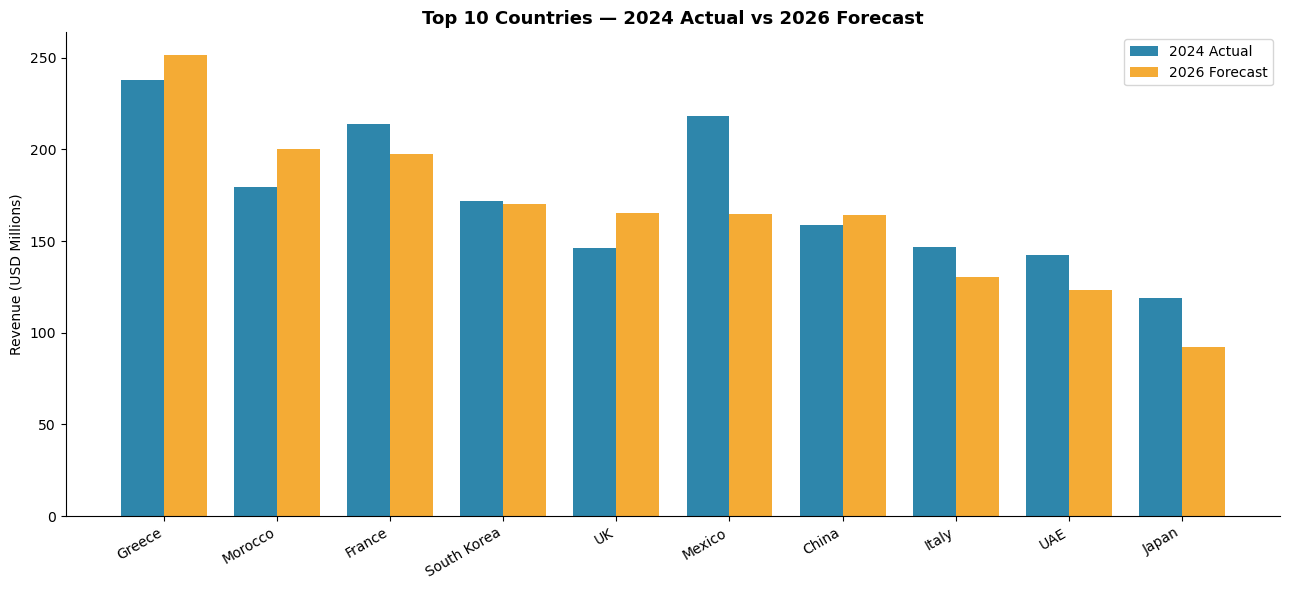

✅ Saved: forecast_by_country.png


In [17]:
# ── 5.2  Plot Top 10 Countries — 2024 vs 2026 ──
country_2026 = df_forecast_country[df_forecast_country['Year']==2026].groupby('Country')['Forecast_Revenue_M'].sum()
country_2024 = country_yearly[country_yearly['Year']==2024].groupby('Country')['Revenue_M'].sum()

compare = pd.DataFrame({
    '2024 Actual':   country_2024,
    '2026 Forecast': country_2026
}).dropna().sort_values('2026 Forecast', ascending=False).head(10)

fig, ax = plt.subplots(figsize=(13, 6))
x = np.arange(len(compare))
width = 0.38
ax.bar(x - width/2, compare['2024 Actual'],   width, label='2024 Actual',   color='#2E86AB')
ax.bar(x + width/2, compare['2026 Forecast'], width, label='2026 Forecast', color='#F39C12', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(compare.index, rotation=30, ha='right')
ax.set_title('Top 10 Countries — 2024 Actual vs 2026 Forecast',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Revenue (USD Millions)')
ax.legend()
plt.tight_layout()
plt.savefig('forecast_by_country.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: forecast_by_country.png")


## 📊 Section 6 — Model Accuracy (Backtesting)

In [22]:
# ── Backtest: Train on 2019-2022, predict 2023-2024, compare to actual ──
# This proves the model is trustworthy

backtest_rows = []
chains_bt = chain_yearly['Chain_ID'].unique()

for chain_id in chains_bt:
    cdata = chain_yearly[chain_yearly['Chain_ID'] == chain_id].sort_values('Year')
    train = cdata[cdata['Year'] <= 2022]
    test  = cdata[cdata['Year'].isin([2023, 2024])]

    if len(train) < 3 or len(test) == 0:
        continue

    X_train = train['Year'].values.reshape(-1, 1)
    y_train = train['Revenue_M'].values
    X_test  = test['Year'].values.reshape(-1, 1)
    y_test  = test['Revenue_M'].values

    model = LinearRegression()
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    for i, yr in enumerate(test['Year'].values):
        backtest_rows.append({
            'Chain_ID': chain_id,
            'Year': yr,
            'Actual_M': round(float(y_test[i]), 3),
            'Predicted_M': round(float(y_pred[i]), 3),
            'Error_M': round(float(y_pred[i] - y_test[i]), 3),
            'Error_Pct': round((y_pred[i] - y_test[i]) / y_test[i] * 100, 2)
        })

df_backtest = pd.DataFrame(backtest_rows)

mae  = mean_absolute_error(df_backtest['Actual_M'], df_backtest['Predicted_M'])
rmse = mean_squared_error(df_backtest['Actual_M'], df_backtest['Predicted_M']) ** 0.5
r2   = r2_score(df_backtest['Actual_M'], df_backtest['Predicted_M'])
mape = (df_backtest['Error_Pct'].abs().mean())

print("=== MODEL ACCURACY (Backtest 2023-2024) ===")
print(f"  MAE  (Mean Absolute Error)    : ${mae:.2f}M")
print(f"  RMSE (Root Mean Sq Error)     : ${rmse:.2f}M")
print(f"  MAPE (Mean Abs % Error)       : {mape:.1f}%")
print(f"  R²   (Variance Explained)     : {r2:.3f}")
print()
print("Rule of thumb: MAPE < 15% = Good model for business forecasting")


=== MODEL ACCURACY (Backtest 2023-2024) ===
  MAE  (Mean Absolute Error)    : $149.14M
  RMSE (Root Mean Sq Error)     : $179.22M
  MAPE (Mean Abs % Error)       : 49.7%
  R²   (Variance Explained)     : -1.343

Rule of thumb: MAPE < 15% = Good model for business forecasting


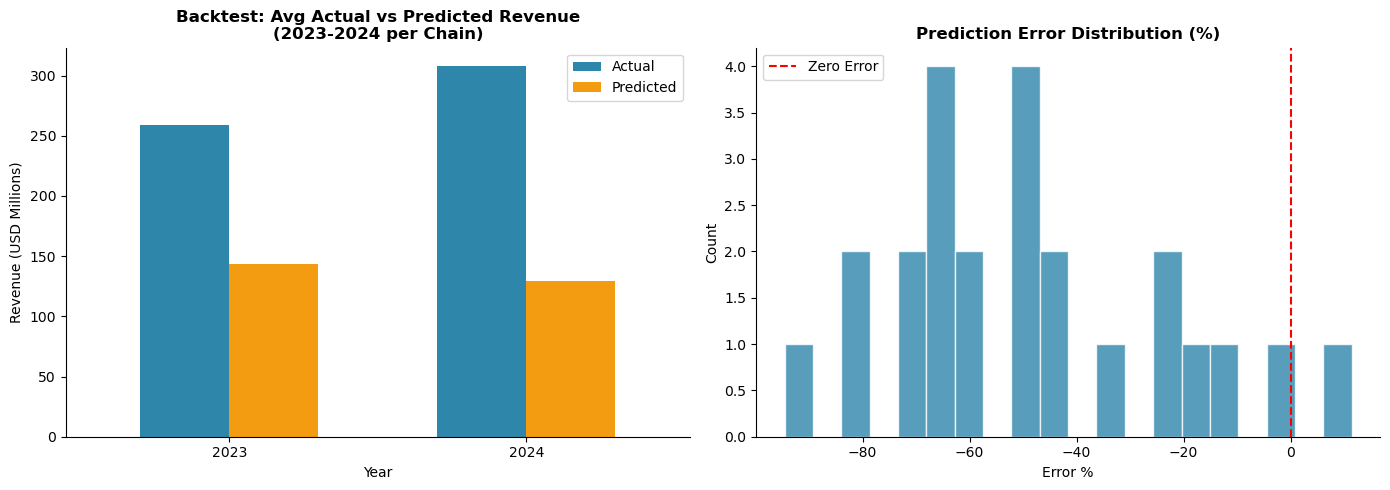

✅ Saved: backtest_accuracy.png


In [24]:
# ── Backtest chart: Actual vs Predicted ──
bt_summary = df_backtest.groupby('Year')[['Actual_M','Predicted_M']].mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar comparison
bt_summary.plot(kind='bar', ax=axes[0], color=['#2E86AB','#F39C12'], width=0.6)
axes[0].set_title('Backtest: Avg Actual vs Predicted Revenue\n(2023-2024 per Chain)',
                  fontweight='bold')
axes[0].set_ylabel('Revenue (USD Millions)')
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(['Actual','Predicted'])

# Error distribution
axes[1].hist(df_backtest['Error_Pct'], bins=20, color='#2E86AB', edgecolor='white', alpha=0.8)
axes[1].axvline(x=0, color='red', linestyle='--', linewidth=1.5, label='Zero Error')
axes[1].set_title('Prediction Error Distribution (%)', fontweight='bold')
axes[1].set_xlabel('Error %')
axes[1].set_ylabel('Count')
axes[1].legend()
plt.tight_layout()
plt.savefig('backtest_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: backtest_accuracy.png")


## 💾 Section 7 — Export Forecast CSV for Power BI

In [25]:
# ── Build master forecast table ──

# 1. Global forecast from Prophet
global_fc = forecast_future[['ds','Year','Quarter','yhat_M','yhat_lower_M','yhat_upper_M']].copy()
global_fc.columns = ['Date','Year','Quarter','Forecast_Revenue_M','Lower_Bound_M','Upper_Bound_M']
global_fc['Scope']   = 'Global'
global_fc['Chain_ID']= 'ALL'
global_fc['Country'] = 'ALL'
global_fc['Model']   = 'Prophet'
global_fc['Data_Type'] = 'Forecast'

# 2. Chain forecast from Linear Regression
chain_fc = df_forecast_chain.copy()
chain_fc['Scope']   = 'Chain'
chain_fc['Country'] = 'ALL'
chain_fc['Lower_Bound_M']  = (chain_fc['Forecast_Revenue_M'] * 0.88).round(3)
chain_fc['Upper_Bound_M']  = (chain_fc['Forecast_Revenue_M'] * 1.12).round(3)
chain_fc['Date'] = pd.to_datetime(
    chain_fc['Year'].astype(str) + '-' +
    chain_fc['Quarter'].map({'Q1':'01','Q2':'04','Q3':'07','Q4':'10'}) + '-01'
)

# 3. Country forecast
country_fc = df_forecast_country.copy()
country_fc['Scope']    = 'Country'
country_fc['Chain_ID'] = 'ALL'
country_fc['Lower_Bound_M'] = (country_fc['Forecast_Revenue_M'] * 0.88).round(3)
country_fc['Upper_Bound_M'] = (country_fc['Forecast_Revenue_M'] * 1.12).round(3)
country_fc['Date'] = pd.to_datetime(
    country_fc['Year'].astype(str) + '-' +
    country_fc['Quarter'].map({'Q1':'01','Q2':'04','Q3':'07','Q4':'10'}) + '-01'
)

# Combine all
cols = ['Date','Year','Quarter','Scope','Chain_ID','Country',
        'Forecast_Revenue_M','Lower_Bound_M','Upper_Bound_M','Model','Data_Type']

df_all_forecast = pd.concat([
    global_fc[cols],
    chain_fc[cols],
    country_fc[cols]
], ignore_index=True)

df_all_forecast.to_csv('hotel_forecast_2026.csv', index=False)
print(f"✅ Exported: hotel_forecast_2026.csv")
print(f"   Total rows : {len(df_all_forecast)}")
print(f"   Scopes     : {df_all_forecast['Scope'].value_counts().to_dict()}")
print(f"   Years      : {sorted(df_all_forecast['Year'].unique())}")
print()
print(df_all_forecast.head(10).to_string(index=False))


✅ Exported: hotel_forecast_2026.csv
   Total rows : 184
   Scopes     : {'Chain': 96, 'Country': 80, 'Global': 8}
   Years      : [np.int64(2025), np.int64(2026)]

      Date  Year Quarter  Scope Chain_ID Country  Forecast_Revenue_M  Lower_Bound_M  Upper_Bound_M             Model Data_Type
2025-01-01  2025      Q1 Global      ALL     ALL             550.130        266.500        810.860           Prophet  Forecast
2025-04-01  2025      Q2 Global      ALL     ALL             715.670        455.290        978.450           Prophet  Forecast
2025-07-01  2025      Q3 Global      ALL     ALL             812.090        545.410       1105.660           Prophet  Forecast
2025-10-01  2025      Q4 Global      ALL     ALL             732.380        475.160       1007.670           Prophet  Forecast
2026-01-01  2026      Q1 Global      ALL     ALL             851.570        572.530       1132.740           Prophet  Forecast
2026-04-01  2026      Q2 Global      ALL     ALL             874.800      

## 📊 Section 8 — Forecast Summary Insights

In [26]:
# ── Summary table ──
global_2026 = global_fc[global_fc['Year']==2026]['Forecast_Revenue_M'].sum()
global_2025 = global_fc[global_fc['Year']==2025]['Forecast_Revenue_M'].sum()

# Get 2024 actual global
actual_2024_M = df_reported[df_reported['Year']==2024]['Revenue_USD'].sum() / 1e6

print("=" * 55)
print("       2026 REVENUE FORECAST SUMMARY")
print("=" * 55)
print(f"  2024 Actual Global Revenue  : ${actual_2024_M:,.1f}M")
print(f"  2025 Forecast               : ${global_2025:,.1f}M")
print(f"  2026 Forecast               : ${global_2026:,.1f}M")
print(f"  Growth 2024 → 2026          : {((global_2026 - actual_2024_M) / actual_2024_M * 100):+.1f}%")
print("=" * 55)
print()

# Top 3 chains by 2026 forecast
top_chains_2026 = df_forecast_chain[df_forecast_chain['Year']==2026].groupby('Chain_ID')['Forecast_Revenue_M'].sum().sort_values(ascending=False)
print("Top Chains by 2026 Forecast:")
for chain, rev in top_chains_2026.head(5).items():
    print(f"  {chain:<10}: ${rev:,.1f}M")
print()

# Top 3 countries by 2026 forecast
top_countries_2026 = df_forecast_country[df_forecast_country['Year']==2026].groupby('Country')['Forecast_Revenue_M'].sum().sort_values(ascending=False)
print("Top Countries by 2026 Forecast:")
for country, rev in top_countries_2026.head(5).items():
    print(f"  {country:<20}: ${rev:,.1f}M")


       2026 REVENUE FORECAST SUMMARY
  2024 Actual Global Revenue  : $3,692.8M
  2025 Forecast               : $2,810.3M
  2026 Forecast               : $3,508.9M
  Growth 2024 → 2026          : -5.0%

Top Chains by 2026 Forecast:
  CHN05     : $508.0M
  CHN01     : $435.7M
  CHN03     : $415.2M
  CHN10     : $381.3M
  CHN04     : $366.6M

Top Countries by 2026 Forecast:
  Greece              : $251.3M
  Morocco             : $200.3M
  France              : $197.6M
  South Korea         : $170.3M
  UK                  : $165.1M


## ✅ Section 9 — How to Use in Power BI

| Step | Action |
|------|--------|
| 1 | Open Power BI Desktop |
| 2 | Get Data → CSV → load `hotel_forecast_2026.csv` |
| 3 | In data model, connect `Chain_ID` to `dim_chain` |
| 4 | Add a new **Page 5 — Forecast** in your dashboard |
| 5 | Line chart: `Date` (x) vs `Forecast_Revenue_M` (y) |
| 6 | Add shaded area using `Lower_Bound_M` and `Upper_Bound_M` |
| 7 | Slicer: filter by `Scope` (Global / Chain / Country) |
| 8 | KPI card: 2026 total forecast vs 2024 actual |

---

**Files generated this notebook:**
- `hotel_forecast_2026.csv` → Power BI forecast page
- `historical_trend.png` → trend chart
- `forecast_global.png` → Prophet forecast chart
- `prophet_components.png` → trend + seasonality breakdown
- `forecast_by_chain.png` → chain comparison
- `forecast_by_country.png` → country comparison
- `backtest_accuracy.png` → model validation

---

## 🎯 Project Status

| Step | Task | Status |
|------|------|--------|
| 1 | Dataset Creation (5,500 rows · 25 countries) | ✅ Done |
| 2 | Star Schema (5 tables) | ✅ Done |
| 3 | Python Cleaning + EDA (Notebook 1) | ✅ Done |
| 4 | SQL Analysis (13 queries) | ✅ Done |
| 5 | Forecasting 2026 (this notebook) | ✅ Done |
| 6 | **Power BI Dashboard (5 pages)** | ⏭️ Next |
| 7 | GitHub + README | ⏭️ Last |
